<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_571/3578004091.py:13: SyntaxWarning: invalid escape sequence '\s'
  $$Z = \frac{\sum X_i - n\mu}{\sigma\sqrt{n}} \approx N(0, 1)$$


Simulating the combination of random factors...


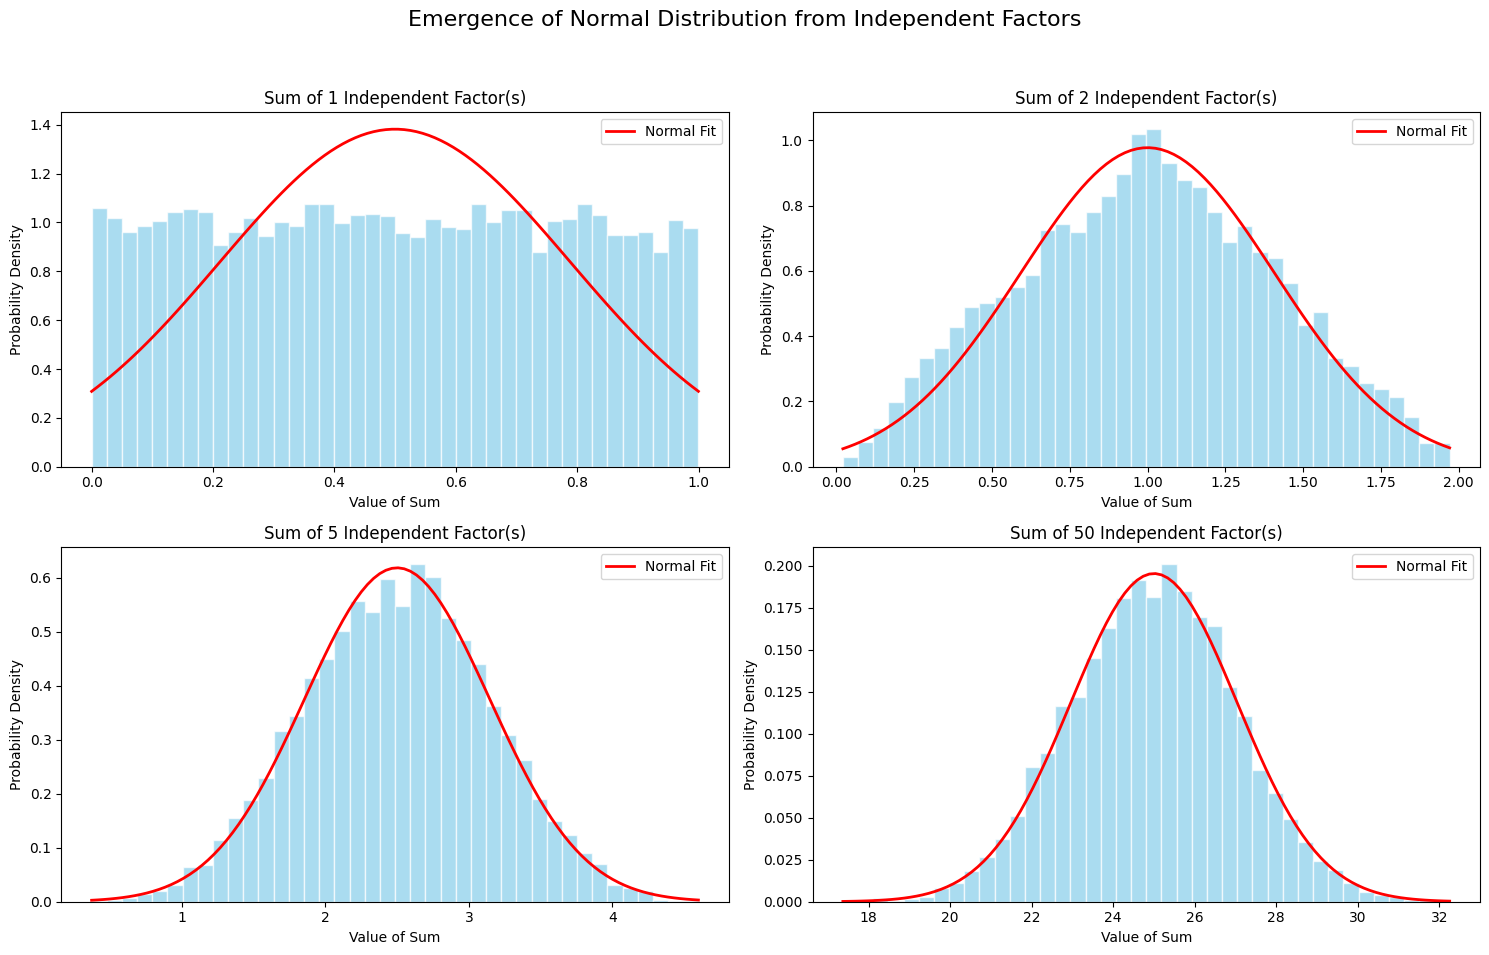

Done! Observe how the 'flat' distribution becomes a 'bell curve'.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

def simulate_central_limit_theorem():
    """
    Demonstrates how independent random factors combine to form
    a Normal (Gaussian) Distribution.

    Formula (Central Limit Theorem):
    As n -> infinity, the distribution of the sum (or mean) of n
    independent and identically distributed (i.i.d) variables approaches:
    $$Z = \frac{\sum X_i - n\mu}{\sigma\sqrt{n}} \approx N(0, 1)$$
    """

    # --- PARAMETERS ---
    num_samples = 10000  # Number of data points in our distribution
    # We will show the distribution as we combine 1, 2, 5, and 50 factors
    factors_to_sum = [1, 2, 5, 50]

    plt.figure(figsize=(15, 10))
    plt.suptitle("Emergence of Normal Distribution from Independent Factors", fontsize=16)

    for i, n in enumerate(factors_to_sum):
        # 1. GENERATE INDEPENDENT FACTORS
        # We use a Uniform Distribution (totally flat, not a bell curve)
        # Each 'factor' is a random number between 0 and 1.
        data = np.random.uniform(0, 1, (num_samples, n))

        # 2. COMBINE THE FACTORS
        # We sum the n factors for each of our 10,000 samples
        combined_data = np.sum(data, axis=1)

        # 3. VISUALIZATION
        plt.subplot(2, 2, i + 1)

        # Plot the histogram of the combined data
        count, bins, ignored = plt.hist(combined_data, bins=40, density=True,
                                        color='skyblue', edgecolor='white', alpha=0.7)

        # 4. OVERLAY THE THEORETICAL GAUSSIAN CURVE
        # For a sum of n uniform variables [0,1]:
        # Mean (mu) = n * 0.5
        # Variance (sigma^2) = n * (1/12)
        mu = n * 0.5
        sigma = np.sqrt(n * (1/12))

        x = np.linspace(min(bins), max(bins), 100)
        plt.plot(x, norm.pdf(x, mu, sigma), color='red', lw=2, label='Normal Fit')

        plt.title(f"Sum of {n} Independent Factor(s)")
        plt.xlabel("Value of Sum")
        plt.ylabel("Probability Density")
        plt.legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# --- Execution ---
if __name__ == "__main__":
    print("Simulating the combination of random factors...")
    simulate_central_limit_theorem()
    print("Done! Observe how the 'flat' distribution becomes a 'bell curve'.")